# Customer Churn Prediction Project

## Introduction
Customer churn prediction is essential for understanding why customers stop using a service and how businesses can improve retention. This project analyzes customer behavior, subscription details, and service usage patterns to identify churn indicators and predict customers at risk of leaving.

### Project Objectives
- Understand the dataset structure  
- Clean and preprocess the data  
- Perform Exploratory Data Analysis (EDA)  
- Visualize insights  
- Build predictive models for churn prediction  
- Provide business recommendations


# Import Libraries

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# 1: Data Collection & Dataset Understanding

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### Insights
- The dataset contains customer demographics, subscriptions, and billing information.
- The target column is **Churn**, which indicates whether a customer left or stayed.
- Both numerical and categorical features exist, requiring preprocessing.


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# 2: Data Cleaning & Preprocessing

In [7]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [10]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [11]:
df.drop_duplicates(inplace=True)

### Insights
- Missing values were handled to avoid model bias.
- Categorical features were encoded into numerical values.
- The dataset became ready for analysis and machine learning.


# Feature Engineering

In [12]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

In [13]:
df["CustomerType"] = np.where(
    df["tenure"] > 24,
    "Loyal",
    "New"
)

### Feature Engineering Insight
New features were created to better understand customer behavior. Long-term customers are categorized separately to identify retention patterns.

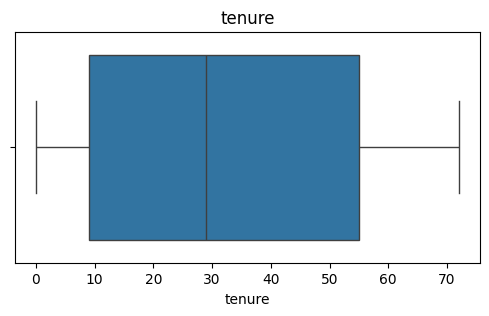

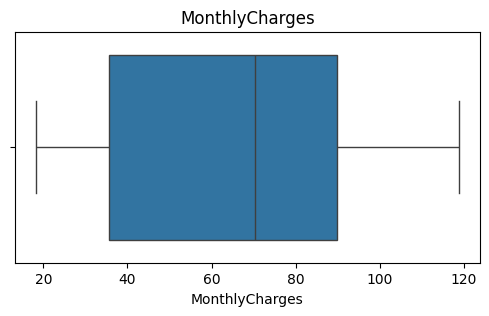

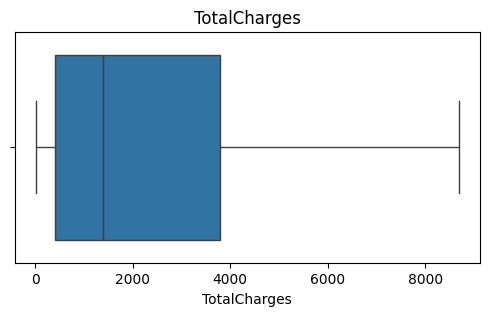

In [14]:
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Insight
Outliers help identify unusual customer spending or subscription behavior.

In [15]:
encoder = LabelEncoder()

for col in df.select_dtypes(
    include="object"
).columns:
    
    df[col] = encoder.fit_transform(
        df[col]
    )

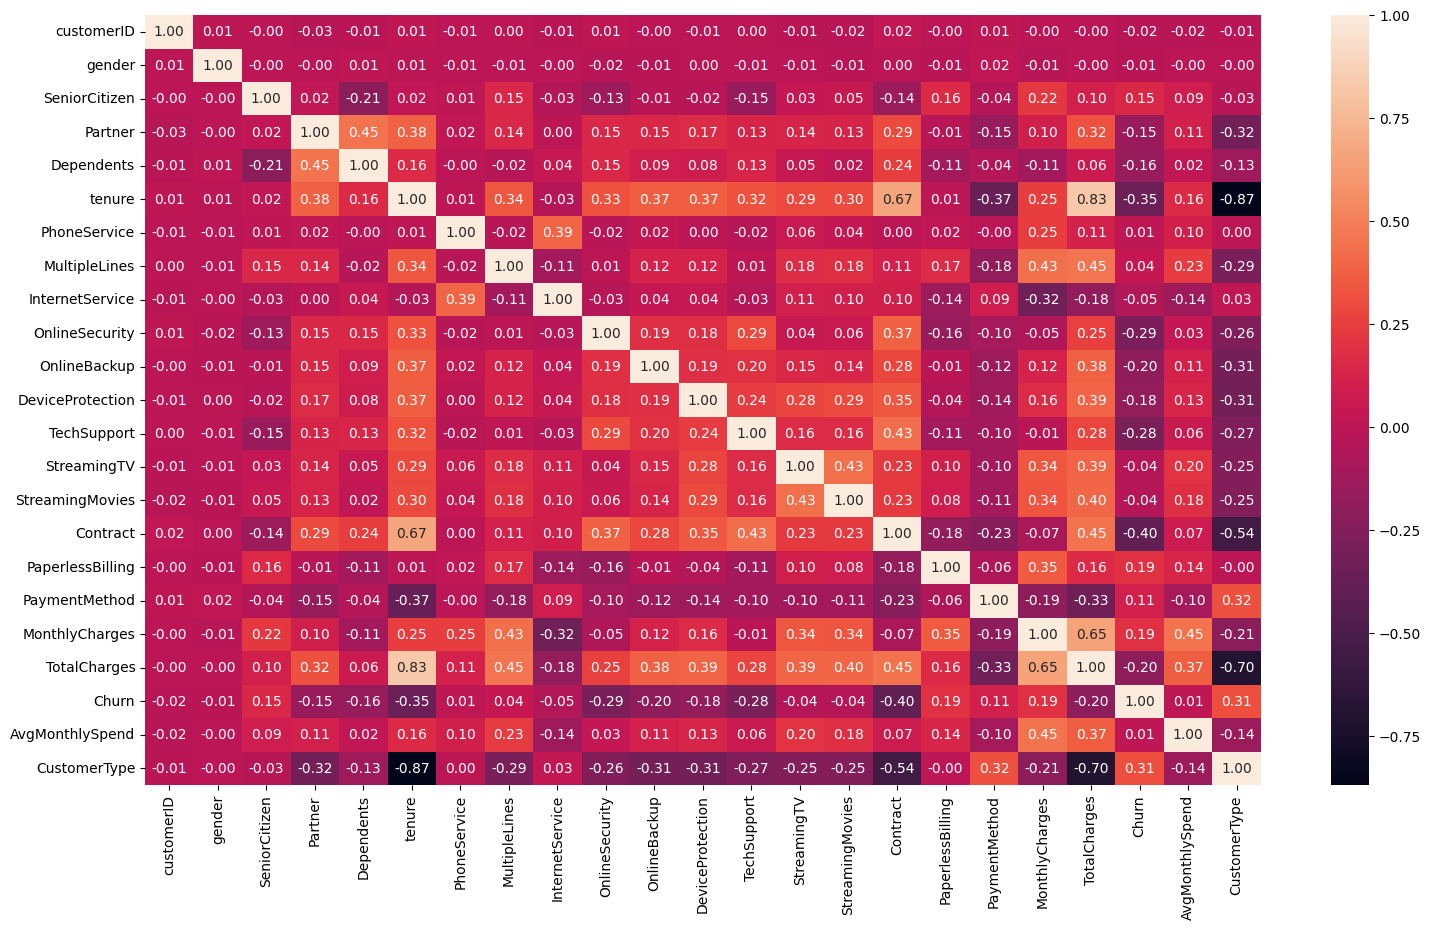

In [16]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.show()

### Insight
Correlation analysis helps identify relationships between variables and churn behavior.

##  3 _ EDA 

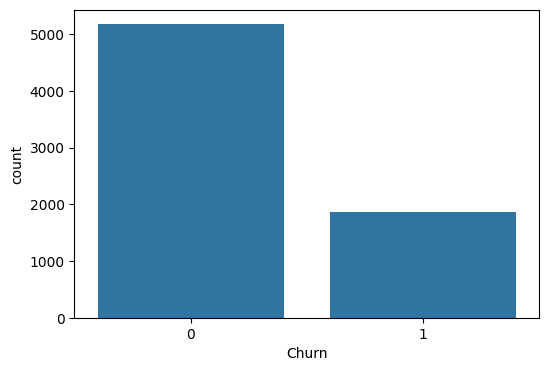

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.show()

### Insight
This visualization shows whether customer churn is balanced or imbalanced.

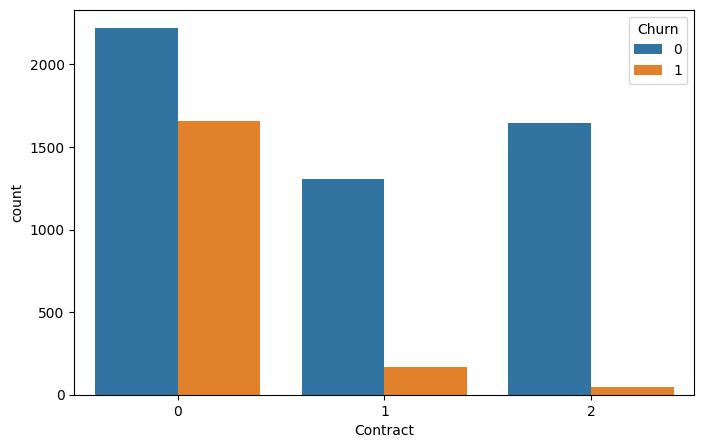

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.show()

### Insight
Customers with month-to-month contracts tend to churn more frequently.

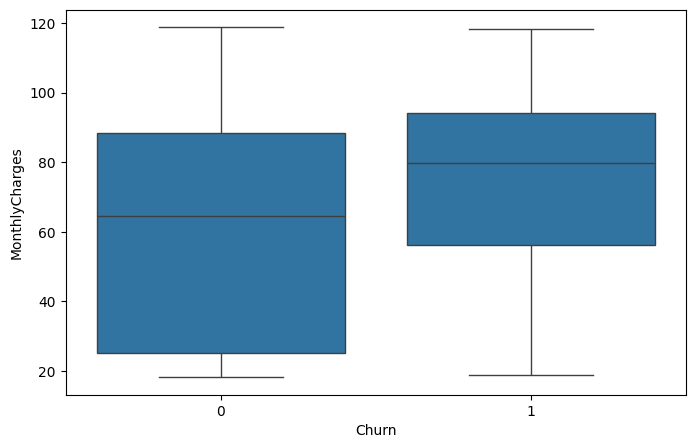

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

### Insight
- Customers with higher monthly charges may churn more frequently.


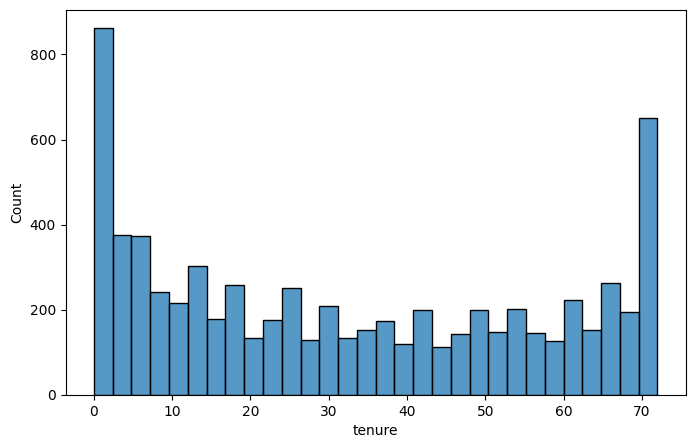

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30
)

plt.show()

### Insight
Long-term customers are more likely to stay compared to new customers.

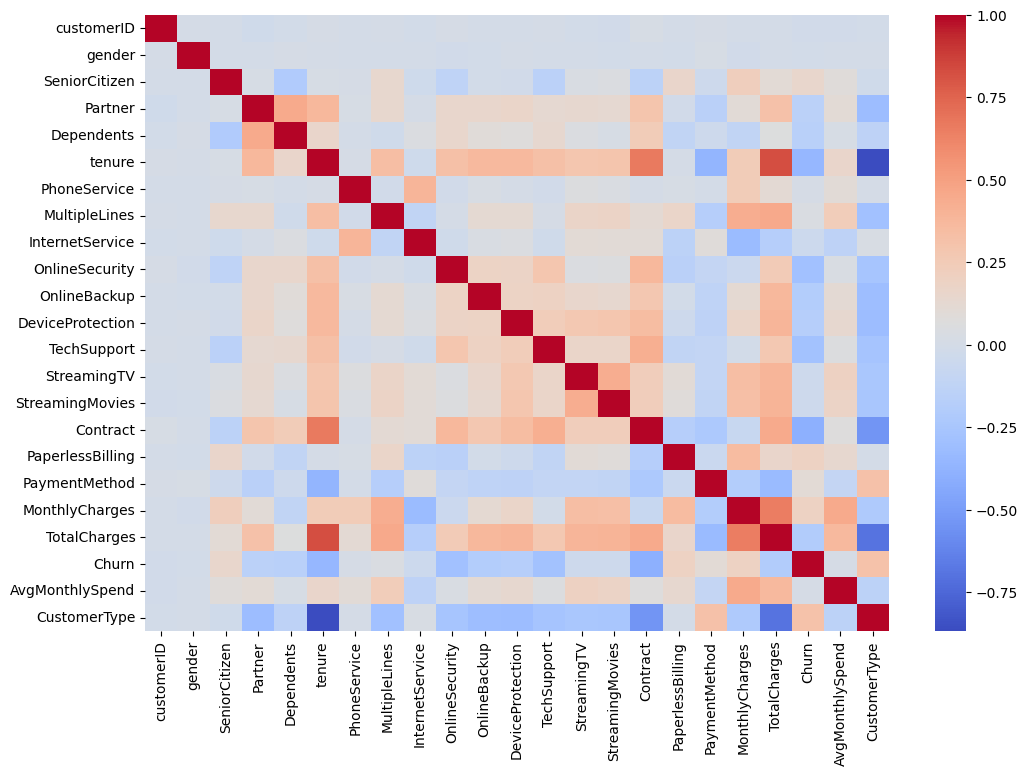

In [21]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

### Key EDA Insights
- Long-term customers tend to churn less.
- Higher monthly charges may increase churn risk.
- Contract type strongly affects churn behavior.
- Customers with multiple services usually stay longer.


# 4 — Visualization

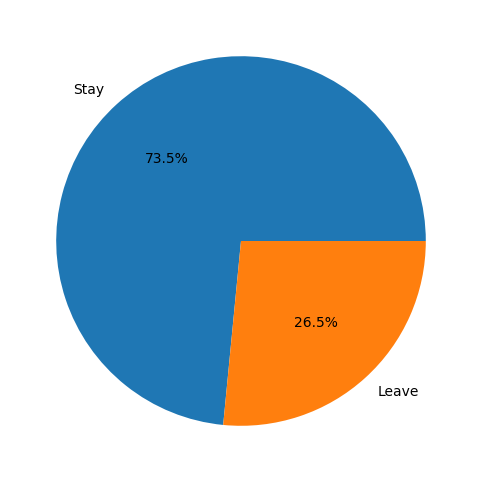

In [22]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=["Stay", "Leave"],
    autopct="%1.1f%%"
)

plt.show()

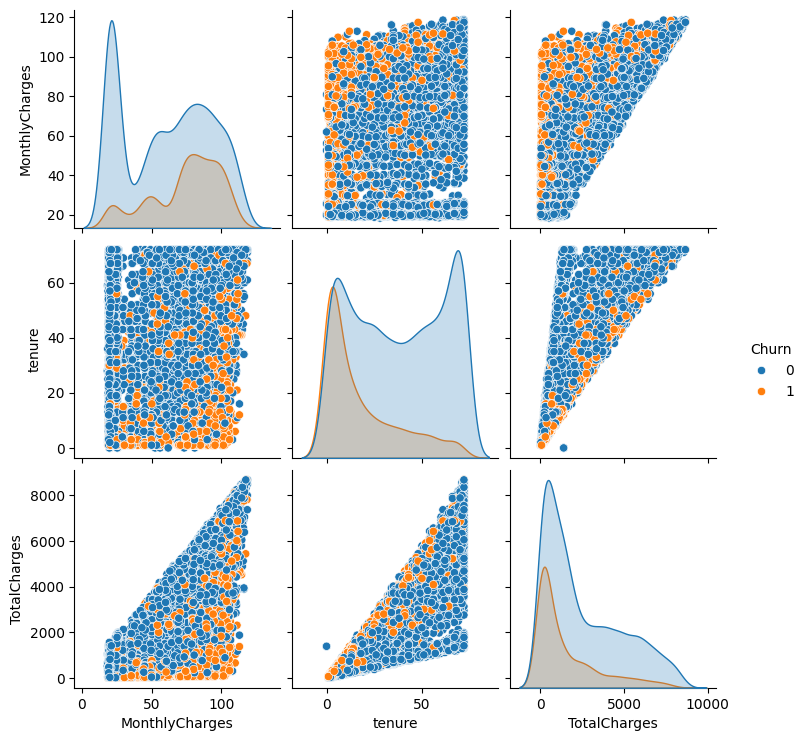

In [23]:
sns.pairplot(
    df[
        [
            "MonthlyCharges",
            "tenure",
            "TotalCharges",
            "Churn"
        ]
    ],
    hue="Churn"
)

plt.show()

# 5: Machine Learning

In [24]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
models = {
    "Logistic Regression":
    LogisticRegression(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(),

    "XGBoost":
    XGBClassifier()
}

results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [28]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810504,0.674342,0.549598,0.605613
3,XGBoost,0.799858,0.642633,0.549598,0.592486
2,Random Forest,0.797019,0.657040,0.487936,0.560000
1,Decision Tree,0.719659,0.471649,0.490617,0.480946


### Insight
Comparing multiple models helps identify the most effective algorithm for churn prediction.

## Confusion Matrix

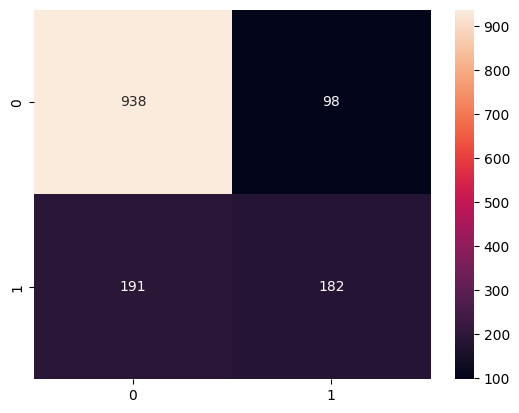

In [29]:
best_model = RandomForestClassifier()

best_model.fit(
    X_train,
    y_train
)

preds = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    preds
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

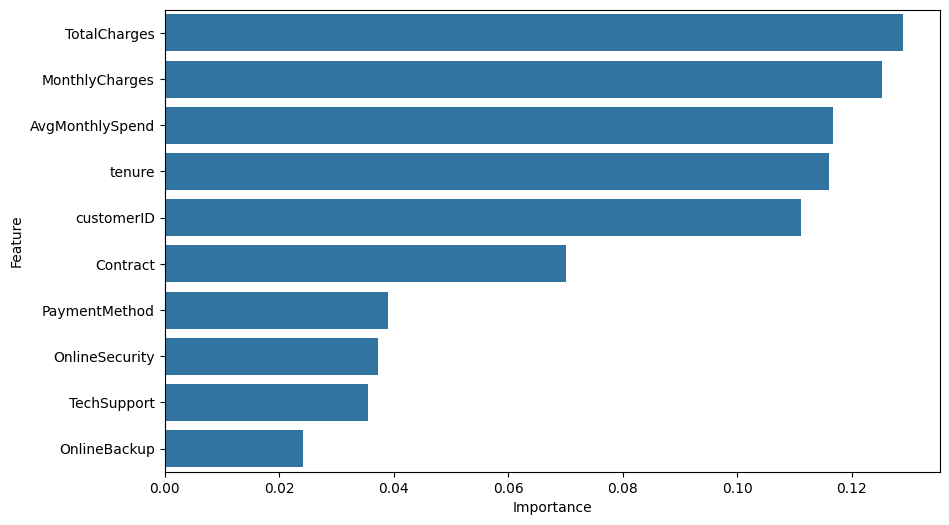

In [30]:
importance = pd.DataFrame({
    "Feature":
    X.columns,

    "Importance":
    best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.show()

# Key Insights

- Customers with higher monthly charges are more likely to churn.

- Long-term customers tend to stay longer.

- Contract type strongly affects customer retention.

- Customers with month-to-month subscriptions have higher churn rates.

- Service engagement significantly impacts retention.

# Business Recommendations

1. Encourage customers to subscribe to long-term contracts.

2. Offer discounts for high monthly charges.

3. Target at-risk customers with personalized offers.

4. Improve engagement for new customers.

# Conclusion

This project successfully analyzed customer churn behavior using data science techniques. Through data preprocessing, visualization, and predictive modeling, meaningful business insights were discovered.

The results suggest that contract type, monthly charges, and customer tenure are major indicators of churn. Predictive models can help businesses proactively identify customers at risk and improve retention strategies.